# Computer Vision — Assignment 2
## Problem Statement 3: Advanced Object Tracking and Detection in Video Streams
**Course:** Computer Vision (S2-25_AIMLCZG525) &nbsp;&nbsp;|&nbsp;&nbsp; **Group:** 12

---

### Objective
Build an **advanced object tracking and detection system** that uses a **Faster R-CNN**
detector to identify and track multiple objects (pedestrians) across the frames of a
video stream, and enhances robustness with two novel techniques:

1. **Temporal consistency checks** — a track is only confirmed after it is detected over
   several consecutive frames, and Kalman smoothing keeps object identities/boxes stable
   when detections briefly flicker or drop out.
2. **Adaptive tracking** — the data-association gate (IoU threshold + track survival age)
   adapts to each object's estimated **speed and direction**, so fast-moving objects are
   matched over larger displacements while slow objects stay tightly gated.

### Dataset
[MOT Challenge](https://motchallenge.net/data/) — the notebook automatically downloads a
**small sample sequence** (`2DMOT2015 / TUD-Stadtmitte`, 179 frames) with ground-truth
pedestrian annotations, so no manual data upload is required.

### Pipeline overview
```
video frames ─► preprocessing/augmentation ─► Faster R-CNN (fine-tuned) ─► detections
             ─► temporal-consistency filter ─► adaptive SORT (Kalman + Hungarian)
             ─► tracked identities ─► evaluation (mAP, MOTA, IDF1, ID-switches, FPS)
```

> **Runtime:** Designed for **Google Colab (GPU)**. `Runtime ▸ Change runtime type ▸ GPU`.


## 1. Environment Setup
Colab already ships with `torch`/`torchvision`. We only install the extra tracking &
evaluation dependencies (`filterpy` for the Kalman filter, `lap` for fast assignment,
`motmetrics` for MOTA/IDF1, `torchmetrics` for mAP).

In [ ]:
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

for mod, pkg in [("filterpy", "filterpy"), ("lap", "lap"),
                 ("motmetrics", "motmetrics"), ("torchmetrics", "torchmetrics"),
                 ("huggingface_hub", "huggingface_hub"), ("cv2", "opencv-python")]:
    try:
        __import__(mod)
    except ImportError:
        print(f"Installing {pkg} ...")
        pip_install([pkg])

# torch / torchvision are pre-installed on Colab; install only if missing (local runs).
try:
    import torch, torchvision  # noqa: F401
except ImportError:
    pip_install(["torch", "torchvision"])
print("Dependencies ready.")

Installing torchmetrics ...
Dependencies ready.


In [1]:
import os, glob, time, random, configparser, urllib.request, zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torchvision
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Set to "cpu" to force CPU, or leave None for automatic best-available selection.
FORCE_DEVICE = None

def pick_device():
    """Auto-select the backend: CUDA (Colab GPU) -> Intel XPU (local) -> CPU."""
    if FORCE_DEVICE:
        return torch.device(FORCE_DEVICE)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        return torch.device("xpu")
    return torch.device("cpu")

DEVICE = pick_device()
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Device:", DEVICE)

torch: 2.9.1+xpu | torchvision: 0.24.1+xpu
Device: xpu


## 2. Data Acquisition
We download one small MOT sequence automatically. `2DMOT2015` sequences are compact and
every ground-truth box is a pedestrian, which keeps preprocessing simple. You can switch
to `MOT16`/`MOT17` by editing the config cell (the parser handles both formats).

In [4]:
# ----------------------------- Configuration -----------------------------
# Default source is a Hugging Face mirror (reachable on most networks).
# motchallenge.net is often firewalled, so it is only a fallback.
SOURCE    = "huggingface"        # {"huggingface", "motchallenge"}
SEQUENCE  = "MOT17-09-FRCNN"     # smallest MOT17 train sequence (525 frames)
DATA_ROOT = "data"

MAX_FRAMES   = 150               # cap frames for fast train/eval (None -> use all)
SCORE_THRESH = 0.70              # detection confidence threshold
EPOCHS       = 3                 # fine-tuning epochs (raise for better accuracy)
BATCH_SIZE   = 2

HF_REPO   = "Lekim89/MOT17"      # MOTChallenge-format MOT17 mirror on Hugging Face

# motchallenge fallback (downloads the whole dataset zip; may be blocked)
MOT_DATASET = "MOT17"
MOT_URLS = {
    "2DMOT2015": "https://motchallenge.net/data/2DMOT2015.zip",
    "MOT16":     "https://motchallenge.net/data/MOT16.zip",
    "MOT17":     "https://motchallenge.net/data/MOT17.zip",
}
os.makedirs(DATA_ROOT, exist_ok=True)

In [5]:
import shutil
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

def _download(url, dst, chunk=1 << 20):
    """Stream a file to disk with THROTTLED progress (used by the motchallenge path).

    A naive urlretrieve prints a progress line per 8 KB block (~65k lines for a
    500 MB file) which floods Colab's output buffer and can crash the session.
    Here we read in 1 MB chunks and print only when the percent advances by >=5%.
    """
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        print("Already downloaded:", dst, f"({os.path.getsize(dst)/1e6:.1f} MB)"); return
    print("Downloading", url)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    tmp = dst + ".part"
    with urllib.request.urlopen(req, timeout=60) as r, open(tmp, "wb") as f:
        total = int(r.headers.get("Content-Length", 0))
        done = 0; last_pct = -5
        while True:
            buf = r.read(chunk)
            if not buf:
                break
            f.write(buf); done += len(buf)
            if total:
                pct = int(done * 100 / total)
                if pct - last_pct >= 5:
                    print(f"  {pct:3d}%  ({done/1e6:6.1f} / {total/1e6:.1f} MB)")
                    last_pct = pct
    shutil.move(tmp, dst)
    print("  done ->", dst, f"({os.path.getsize(dst)/1e6:.1f} MB)")

def download_sequence_hf(repo, sequence, root, max_frames=None):
    """Fetch a single MOT sequence from a Hugging Face dataset mirror.

    Only the requested frames + gt + seqinfo are downloaded (via allow_patterns),
    so this stays small even though the full dataset is large.
    """
    from huggingface_hub import snapshot_download
    patterns = [f"train/{sequence}/seqinfo.ini", f"train/{sequence}/gt/*"]
    if max_frames:
        patterns += [f"train/{sequence}/img1/{i:06d}.jpg" for i in range(1, max_frames + 1)]
    else:
        patterns += [f"train/{sequence}/img1/*"]
    print(f"Downloading '{sequence}' from HF dataset '{repo}' "
          f"({'first %d frames' % max_frames if max_frames else 'all frames'}) ...")
    path = snapshot_download(repo_id=repo, repo_type="dataset", allow_patterns=patterns)
    seq_dir = os.path.join(path, "train", sequence)
    print("Sequence ready:", seq_dir)
    return seq_dir

def download_sequence_motchallenge(dataset, sequence, root):
    seq_dir = os.path.join(root, dataset, "train", sequence)
    if os.path.isdir(os.path.join(seq_dir, "img1")):
        print("Sequence present:", seq_dir); return seq_dir
    zip_path = os.path.join(root, f"{dataset}.zip")
    _download(MOT_URLS[dataset], zip_path)
    if not zipfile.is_zipfile(zip_path):
        raise RuntimeError(
            f"{zip_path} is not a valid zip (download blocked or an error page "
            f"was returned). Try re-running, or download {MOT_URLS[dataset]} "
            f"manually and place it at {zip_path}.")
    print("Extracting sequence:", sequence)
    with zipfile.ZipFile(zip_path) as zf:
        members = [m for m in zf.namelist()
                   if f"train/{sequence}/" in m.replace("\\", "/")]
        if not members:
            members = [m for m in zf.namelist()
                       if f"/{sequence}/" in m.replace("\\", "/")]
        if not members:
            raise RuntimeError(f"Sequence '{sequence}' not found inside {zip_path}.")
        zf.extractall(root, members)
    hits = glob.glob(os.path.join(root, "**", sequence, "img1"), recursive=True)
    seq_dir = os.path.dirname(hits[0]) if hits else seq_dir
    print("Sequence ready:", seq_dir)
    return seq_dir

if SOURCE == "huggingface":
    SEQ_DIR = download_sequence_hf(HF_REPO, SEQUENCE, DATA_ROOT, MAX_FRAMES)
else:
    SEQ_DIR = download_sequence_motchallenge(MOT_DATASET, SEQUENCE, DATA_ROOT)

c:\manju\personal\MTech\Sem2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 152 files: 100%|██████████| 152/152 [00:50<00:00,  3.01it/s]

Sequence ready: C:\Users\manjusub\.cache\huggingface\hub\datasets--Lekim89--MOT17\snapshots\f93908467986c77765667925a526ad07be8ad630\train\MOT17-09-FRCNN


## 3. Data Preprocessing
We parse `seqinfo.ini` for frame metadata, load the frame paths, and read the
ground-truth annotations (`gt/gt.txt`). MOT ground truth is stored as
`frame, id, bb_left, bb_top, bb_width, bb_height, conf, [class, visibility]`.
For MOT16/17 we keep only pedestrian class 1 with `conf==1`.

In [6]:
def parse_seqinfo(seq_dir):
    ini = os.path.join(seq_dir, "seqinfo.ini")
    cfg = configparser.ConfigParser()
    cfg.read(ini)
    s = cfg["Sequence"]
    return {
        "name": s.get("name", os.path.basename(seq_dir)),
        "imDir": s.get("imDir", "img1"),
        "frameRate": int(s.get("frameRate", 25)),
        "seqLength": int(s.get("seqLength", 0)),
        "imWidth": int(s.get("imWidth", 0)),
        "imHeight": int(s.get("imHeight", 0)),
        "imExt": s.get("imExt", ".jpg"),
    }

def load_frames(seq_dir, info):
    img_dir = os.path.join(seq_dir, info["imDir"])
    frames = sorted(glob.glob(os.path.join(img_dir, f"*{info['imExt']}")))
    return frames

def load_gt(seq_dir):
    '''Return {frame_idx(1-based): [(track_id, x1,y1,x2,y2), ...]}.'''
    path = os.path.join(seq_dir, "gt", "gt.txt")
    gt = {}
    if not os.path.exists(path):
        print("No gt.txt found (test split?)."); return gt
    data = np.atleast_2d(np.loadtxt(path, delimiter=","))
    for row in data:
        fr, tid = int(row[0]), int(row[1])
        x, y, w, h = row[2], row[3], row[4], row[5]
        conf = row[6] if len(row) > 6 else 1
        cls  = int(row[7]) if len(row) > 7 else 1
        if len(row) > 7 and (conf == 0 or cls != 1):
            continue   # MOT16/17: keep only active pedestrians
        gt.setdefault(fr, []).append((tid, x, y, x + w, y + h))
    return gt

INFO   = parse_seqinfo(SEQ_DIR)
FRAMES = load_frames(SEQ_DIR, INFO)
GT     = load_gt(SEQ_DIR)

# Cap to MAX_FRAMES so training/eval stay fast; keep GT aligned to used frames.
if MAX_FRAMES:
    FRAMES = FRAMES[:MAX_FRAMES]
GT = {f: v for f, v in GT.items() if f <= len(FRAMES)}

print(INFO)
print(f"#frames used = {len(FRAMES)} | #annotated frames = {len(GT)}")

{'name': 'MOT17-09-FRCNN', 'imDir': 'img1', 'frameRate': 30, 'seqLength': 525, 'imWidth': 1920, 'imHeight': 1080, 'imExt': '.jpg'}
#frames used = 150 | #annotated frames = 150


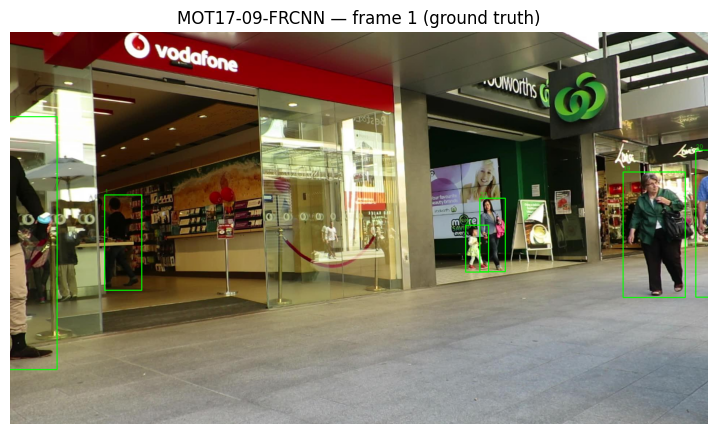

In [7]:
# Visualise a sample frame with its ground-truth boxes
def show_frame_with_boxes(idx=0):
    img = cv2.cvtColor(cv2.imread(FRAMES[idx]), cv2.COLOR_BGR2RGB)
    for tid, x1, y1, x2, y2 in GT.get(idx + 1, []):
        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(img, str(tid), (int(x1), int(y1) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    plt.figure(figsize=(9, 6)); plt.imshow(img)
    plt.title(f"{INFO['name']} — frame {idx + 1} (ground truth)"); plt.axis("off"); plt.show()

show_frame_with_boxes(0)

### 3.1 Detection Dataset & Data Augmentation
We build a `torch.utils.data.Dataset` that yields `(image_tensor, target)` where the
target holds pedestrian boxes/labels. Augmentation (**random horizontal flip, random crop,
and color jitter**) improves robustness; boxes are transformed consistently and degenerate
boxes are filtered. Frames are split temporally: first 80% for training, last 20% for
validation/evaluation.

In [8]:
import torchvision.transforms.functional as TF
from torchvision.transforms import ColorJitter

class Compose:
    def __init__(self, tfms): self.tfms = tfms
    def __call__(self, img, tgt):
        for t in self.tfms: img, tgt = t(img, tgt)
        return img, tgt

class RandomHorizontalFlip:
    def __init__(self, p=0.5): self.p = p
    def __call__(self, img, tgt):
        if random.random() < self.p:
            W = img.width
            img = TF.hflip(img)
            b = tgt["boxes"].clone()
            b[:, [0, 2]] = W - b[:, [2, 0]]
            tgt["boxes"] = b
        return img, tgt

class RandomColorJitter:
    def __init__(self, p=0.5):
        self.p = p
        self.jit = ColorJitter(0.2, 0.2, 0.2, 0.05)
    def __call__(self, img, tgt):
        if random.random() < self.p:
            img = self.jit(img)
        return img, tgt

class RandomCrop:
    '''Crop a random 80-100% sub-window; keep boxes whose centre stays inside.'''
    def __init__(self, p=0.5): self.p = p
    def __call__(self, img, tgt):
        if random.random() > self.p or len(tgt["boxes"]) == 0:
            return img, tgt
        W, H = img.width, img.height
        cw, ch = int(W * random.uniform(0.8, 1.0)), int(H * random.uniform(0.8, 1.0))
        x0, y0 = random.randint(0, W - cw), random.randint(0, H - ch)
        b = tgt["boxes"].clone()
        cx, cy = (b[:, 0] + b[:, 2]) / 2, (b[:, 1] + b[:, 3]) / 2
        keep = (cx >= x0) & (cx < x0 + cw) & (cy >= y0) & (cy < y0 + ch)
        if keep.sum() == 0:
            return img, tgt
        b = b[keep]
        b[:, [0, 2]] = b[:, [0, 2]].clamp(x0, x0 + cw) - x0
        b[:, [1, 3]] = b[:, [1, 3]].clamp(y0, y0 + ch) - y0
        img = TF.crop(img, y0, x0, ch, cw)
        tgt = {"boxes": b, "labels": tgt["labels"][keep]}
        return img, tgt

class ToTensor:
    def __call__(self, img, tgt):
        return TF.to_tensor(img), tgt

def valid_boxes(tgt):
    b = tgt["boxes"]
    keep = (b[:, 2] > b[:, 0]) & (b[:, 3] > b[:, 1])
    return {"boxes": b[keep], "labels": tgt["labels"][keep]}

In [12]:
class MOTDetectionDataset(torch.utils.data.Dataset):
    PERSON = 1  # single foreground class
    def __init__(self, frames, gt, indices, transforms=None):
        self.frames, self.gt = frames, gt
        self.indices, self.transforms = indices, transforms
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        img = Image.open(self.frames[idx]).convert("RGB")
        boxes = [[x1, y1, x2, y2] for _, x1, y1, x2, y2 in self.gt.get(idx + 1, [])]
        boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        target = {"boxes": boxes,
                  "labels": torch.ones((len(boxes),), dtype=torch.int64)}
        if self.transforms:
            img, target = self.transforms(img, target)
        else:
            img = TF.to_tensor(img)
        return img, valid_boxes(target)

def collate_fn(batch):
    return tuple(zip(*batch))

n = len(FRAMES)
split = int(n * 0.8)
train_idx = list(range(0, split))
val_idx   = list(range(split, n))

train_tfms = Compose([RandomHorizontalFlip(0.5), RandomCrop(0.4),
                      RandomColorJitter(0.5), ToTensor()])
train_ds = MOTDetectionDataset(FRAMES, GT, train_idx, train_tfms)
val_ds   = MOTDetectionDataset(FRAMES, GT, val_idx, Compose([ToTensor()]))

# num_workers=0 for cross-platform safety: on Windows notebook kernels, worker
# subprocesses cannot pickle the locally-defined dataset/transform classes.
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                           collate_fn=collate_fn, num_workers=0)
print(f"train frames = {len(train_ds)} | val frames = {len(val_ds)}")

train frames = 120 | val frames = 30


## 4. Model Development — Faster R-CNN
We start from a **COCO-pretrained `fasterrcnn_resnet50_fpn`** and replace the box
predictor head with a 2-class head (`background`, `pedestrian`). Transfer learning from
COCO (which already knows the *person* class) lets us fine-tune effectively on a small
sequence. We keep the **COCO-pretrained model as a baseline detector** for comparison.

In [10]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

COCO_PERSON = 1  # 'person' label id in COCO

def build_finetune_model(num_classes=2):
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes)
    return model

# Baseline: the untouched COCO detector (person detections only)
baseline_model = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT).to(DEVICE).eval()

# Fine-tuned model
model = build_finetune_model(num_classes=2).to(DEVICE)
print("Models built.")

Models built.


### 4.1 Fine-tuning
We fine-tune with SGD (momentum) and a step LR schedule for a few epochs. Loss is the sum
of the Faster R-CNN RPN and ROI losses returned by torchvision in training mode.

Epoch 1/3 — mean loss 0.4404
Epoch 2/3 — mean loss 0.2435
Epoch 3/3 — mean loss 0.1910


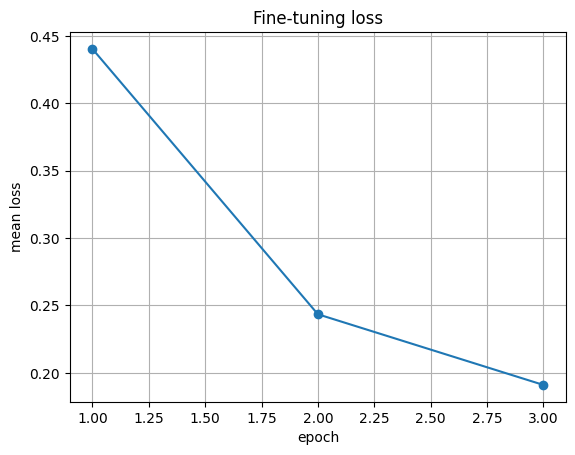

Fine-tuning complete.


In [13]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=5e-4)
lr_sched  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

history = []
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for images, targets in train_loader:
        images = [im.to(DEVICE) for im in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        # skip batches with no boxes
        if all(len(t["boxes"]) == 0 for t in targets):
            continue
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()
    lr_sched.step()
    avg = running / max(1, len(train_loader))
    history.append(avg)
    print(f"Epoch {epoch + 1}/{EPOCHS} — mean loss {avg:.4f}")

plt.plot(range(1, len(history) + 1), history, marker="o")
plt.title("Fine-tuning loss"); plt.xlabel("epoch"); plt.ylabel("mean loss")
plt.grid(True); plt.show()
model.eval(); print("Fine-tuning complete.")

## 5. Detection Evaluation (mAP)
We run both detectors on the held-out validation frames and compute **mean Average
Precision** with a small, self-contained implementation (COCO-style 101-point
interpolation, no `pycocotools` dependency). Boxes are filtered to the *person* class.
This isolates detector quality before tracking.

In [15]:
@torch.no_grad()
def detect(model_, img_tensor, person_label, score_thresh=SCORE_THRESH):
    '''Return (boxes_xyxy[np], scores[np]) for the person class.'''
    out = model_([img_tensor.to(DEVICE)])[0]
    keep = (out["labels"] == person_label) & (out["scores"] >= score_thresh)
    return (out["boxes"][keep].cpu().numpy(),
            out["scores"][keep].cpu().numpy())

# --- self-contained mAP (no pycocotools/torchmetrics needed) --------------
def _iou_one_to_many(box, boxes):
    if len(boxes) == 0:
        return np.zeros((0,), dtype=np.float32)
    xx1 = np.maximum(box[0], boxes[:, 0]); yy1 = np.maximum(box[1], boxes[:, 1])
    xx2 = np.minimum(box[2], boxes[:, 2]); yy2 = np.minimum(box[3], boxes[:, 3])
    w = np.clip(xx2 - xx1, 0, None); h = np.clip(yy2 - yy1, 0, None)
    inter = w * h
    area = (box[2] - box[0]) * (box[3] - box[1])
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return inter / (area + areas - inter + 1e-9)

def _ap_at_iou(preds, gts, iou_thr):
    '''preds: list per image of (boxes[N,4], scores[N]); gts: list of boxes[M,4].'''
    dets = [(s[j], i, b[j]) for i, (b, s) in enumerate(preds) for j in range(len(b))]
    n_gt = sum(len(g) for g in gts)
    if n_gt == 0:
        return 0.0
    dets.sort(key=lambda x: -x[0])
    matched = [np.zeros(len(g), dtype=bool) for g in gts]
    tp = np.zeros(len(dets)); fp = np.zeros(len(dets))
    for k, (sc, i, box) in enumerate(dets):
        ious = _iou_one_to_many(box, gts[i])
        if len(ious) and ious.max() >= iou_thr and not matched[i][int(ious.argmax())]:
            tp[k] = 1; matched[i][int(ious.argmax())] = True
        else:
            fp[k] = 1
    tp_c, fp_c = np.cumsum(tp), np.cumsum(fp)
    recall = tp_c / (n_gt + 1e-9)
    precision = tp_c / (tp_c + fp_c + 1e-9)
    ap = 0.0                                   # COCO 101-point interpolation
    for t in np.linspace(0, 1, 101):
        p = precision[recall >= t].max() if np.any(recall >= t) else 0.0
        ap += p / 101
    return float(ap)

def eval_detection_map(model_, person_label, name):
    model_.eval()
    preds, gts = [], []
    for idx in val_idx:
        img = TF.to_tensor(Image.open(FRAMES[idx]).convert("RGB"))
        boxes, scores = detect(model_, img, person_label, score_thresh=0.05)
        preds.append((boxes, scores))
        gts.append(np.array([[x1, y1, x2, y2]
                             for _, x1, y1, x2, y2 in GT.get(idx + 1, [])]).reshape(-1, 4))
    ap50 = _ap_at_iou(preds, gts, 0.5)
    mAP  = float(np.mean([_ap_at_iou(preds, gts, t) for t in np.arange(0.5, 1.0, 0.05)]))
    print(f"[{name}] mAP@0.50:0.95 = {mAP:.3f} | mAP@0.50 = {ap50:.3f}")
    return {"map": mAP, "map_50": ap50}

map_baseline  = eval_detection_map(baseline_model, COCO_PERSON, "Baseline (COCO)")
map_finetuned = eval_detection_map(model, MOTDetectionDataset.PERSON, "Fine-tuned")

[Baseline (COCO)] mAP@0.50:0.95 = 0.449 | mAP@0.50 = 0.591
[Fine-tuned] mAP@0.50:0.95 = 0.517 | mAP@0.50 = 0.693


## 6. Tracking — Adaptive SORT with Temporal Consistency
We implement **SORT** (Simple Online and Realtime Tracking): each track is a **Kalman
filter** in `[cx, cy, area, aspect]` state space with constant-velocity motion; detections
are matched to predicted tracks by **IoU + Hungarian assignment**.

**Novel enhancements added on top of vanilla SORT:**

* **Temporal consistency check** — a track must accumulate `min_hits` detections in
  consecutive frames before its identity is emitted, which removes one-frame false
  positives; the Kalman filter also *coasts* a track for up to `max_age` frames when a
  detection is momentarily missed, keeping IDs stable.
* **Adaptive tracking** — the association gate is a function of each track's estimated
  **speed** (Kalman velocity magnitude). Fast objects relax their IoU threshold and get a
  longer survival age, so large frame-to-frame displacements still match; slow objects stay
  tightly gated to avoid ID swaps.

In [16]:
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment

def iou_batch(a, b):
    '''IoU between boxes a[N,4] and b[M,4] in xyxy.'''
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=np.float32)
    a, b = a[:, None, :], b[None, :, :]
    xx1 = np.maximum(a[..., 0], b[..., 0]); yy1 = np.maximum(a[..., 1], b[..., 1])
    xx2 = np.minimum(a[..., 2], b[..., 2]); yy2 = np.minimum(a[..., 3], b[..., 3])
    w = np.clip(xx2 - xx1, 0, None); h = np.clip(yy2 - yy1, 0, None)
    inter = w * h
    area_a = (a[..., 2] - a[..., 0]) * (a[..., 3] - a[..., 1])
    area_b = (b[..., 2] - b[..., 0]) * (b[..., 3] - b[..., 1])
    return inter / (area_a + area_b - inter + 1e-9)

def xyxy_to_z(box):
    w = box[2] - box[0]; h = box[3] - box[1]
    cx = box[0] + w / 2.; cy = box[1] + h / 2.
    s = w * h; r = w / (h + 1e-6)
    return np.array([cx, cy, s, r]).reshape(4, 1)

def z_to_xyxy(x):
    cx, cy, s, r = x[0], x[1], x[2], x[3]
    w = np.sqrt(abs(s) * abs(r)); h = s / (w + 1e-6)
    return np.array([cx - w / 2., cy - h / 2., cx + w / 2., cy + h / 2.]).reshape(-1)

In [17]:
class KalmanBoxTracker:
    count = 0
    def __init__(self, box):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1,0,0,0,1,0,0],[0,1,0,0,0,1,0],[0,0,1,0,0,0,1],
                              [0,0,0,1,0,0,0],[0,0,0,0,1,0,0],[0,0,0,0,0,1,0],
                              [0,0,0,0,0,0,1]], dtype=float)
        self.kf.H = np.array([[1,0,0,0,0,0,0],[0,1,0,0,0,0,0],
                              [0,0,1,0,0,0,0],[0,0,0,1,0,0,0]], dtype=float)
        self.kf.R[2:, 2:] *= 10.
        self.kf.P[4:, 4:] *= 1000.; self.kf.P *= 10.
        self.kf.Q[-1, -1] *= 0.01; self.kf.Q[4:, 4:] *= 0.01
        self.kf.x[:4] = xyxy_to_z(box)
        self.id = KalmanBoxTracker.count; KalmanBoxTracker.count += 1
        self.time_since_update = 0
        self.hits = 0; self.hit_streak = 0; self.age = 0
    def update(self, box):
        self.time_since_update = 0
        self.hits += 1; self.hit_streak += 1
        self.kf.update(xyxy_to_z(box))
    def predict(self):
        if self.kf.x[6] + self.kf.x[2] <= 0:
            self.kf.x[6] *= 0.0
        self.kf.predict()
        self.age += 1
        if self.time_since_update > 0:
            self.hit_streak = 0
        self.time_since_update += 1
        return z_to_xyxy(self.kf.x)
    def get_state(self):
        return z_to_xyxy(self.kf.x)
    def speed(self):
        # kf.x is a (7,1) column vector -> index [i, 0] to get scalars
        return float(np.hypot(self.kf.x[4, 0], self.kf.x[5, 0]))  # |velocity| px/frame

In [18]:
class AdaptiveSort:
    '''SORT with adaptive gating + temporal-consistency confirmation.'''
    def __init__(self, max_age=15, min_hits=3, iou_base=0.3, adaptive=True):
        self.max_age = max_age; self.min_hits = min_hits
        self.iou_base = iou_base; self.adaptive = adaptive
        self.trackers = []; self.frame_count = 0

    def _gate(self, trk):
        '''Adaptive IoU threshold: faster tracks -> lower threshold.'''
        if not self.adaptive:
            return self.iou_base
        return max(0.1, self.iou_base - 0.02 * min(trk.speed(), 10.0))

    def update(self, dets):
        self.frame_count += 1
        preds = np.array([t.predict() for t in self.trackers]).reshape(-1, 4)
        matches, un_dets, un_trks = self._associate(dets, preds)
        for d, t in matches:
            self.trackers[t].update(dets[d])
        for d in un_dets:
            self.trackers.append(KalmanBoxTracker(dets[d]))
        out = []
        for t in reversed(range(len(self.trackers))):
            trk = self.trackers[t]
            # adaptive survival: fast tracks may coast a little longer
            eff_age = self.max_age + (5 if self.adaptive and trk.speed() > 5 else 0)
            if trk.time_since_update > eff_age:
                self.trackers.pop(t); continue
            # temporal-consistency: emit only confirmed tracks
            if trk.time_since_update < 1 and (
                    trk.hit_streak >= self.min_hits or self.frame_count <= self.min_hits):
                box = trk.get_state()
                out.append(np.concatenate([box, [trk.id + 1]]))
        return np.array(out).reshape(-1, 5)

    def _associate(self, dets, preds):
        if len(preds) == 0:
            return [], list(range(len(dets))), []
        if len(dets) == 0:
            return [], [], list(range(len(preds)))
        iou = iou_batch(dets, preds)
        row, col = linear_sum_assignment(-iou)
        matches, un_dets, un_trks = [], [], []
        matched_d, matched_t = set(), set()
        for d, t in zip(row, col):
            if iou[d, t] >= self._gate(self.trackers[t]):
                matches.append((d, t)); matched_d.add(d); matched_t.add(t)
        un_dets = [d for d in range(len(dets)) if d not in matched_d]
        un_trks = [t for t in range(len(preds)) if t not in matched_t]
        return matches, un_dets, un_trks

### 6.1 Baseline tracker (for comparison)
A simple **greedy IoU tracker** without a Kalman filter, adaptive gating, or temporal
confirmation. Comparing against it isolates the benefit of our enhancements.

In [19]:
class GreedyIouTracker:
    def __init__(self, iou_thresh=0.3, max_age=1):
        self.iou_thresh = iou_thresh; self.max_age = max_age
        self.tracks = []  # each: {box, id, age}
        self.next_id = 1
    def update(self, dets):
        preds = np.array([t["box"] for t in self.tracks]).reshape(-1, 4)
        iou = iou_batch(dets, preds)
        assigned = set(); out = []
        for d in range(len(dets)):
            j = int(np.argmax(iou[d])) if len(preds) else -1
            if j >= 0 and j not in assigned and iou[d, j] >= self.iou_thresh:
                self.tracks[j].update(box=dets[d], age=0); assigned.add(j)
                out.append(np.concatenate([dets[d], [self.tracks[j]["id"]]]))
            else:
                self.tracks.append({"box": dets[d], "id": self.next_id, "age": 0})
                out.append(np.concatenate([dets[d], [self.next_id]])); self.next_id += 1
        for j, t in enumerate(self.tracks):
            if j not in assigned:
                t["age"] += 1
        self.tracks = [t for t in self.tracks if t["age"] <= self.max_age]
        return np.array(out).reshape(-1, 5)

## 7. Run the Tracking Pipeline
We run the full sequence through the fine-tuned detector and each tracker, storing results
in **MOT format** (`frame, id, x, y, w, h`) for evaluation, and measuring detection+tracking
**speed (FPS)**.

In [20]:
def run_tracking(detector, person_label, tracker, frames, save_video=None):
    KalmanBoxTracker.count = 0
    results = {}   # frame_idx(1-based) -> list[(id, x1,y1,x2,y2)]
    writer = None
    t0 = time.time()
    for idx, fpath in enumerate(frames):
        img_bgr = cv2.imread(fpath)
        img_t = TF.to_tensor(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        boxes, scores = detect(detector, img_t, person_label)
        tracks = tracker.update(boxes.astype(float))
        frame_res = []
        for tr in tracks:
            x1, y1, x2, y2, tid = tr
            frame_res.append((int(tid), x1, y1, x2, y2))
            if save_video is not None:
                c = (int(37 * tid) % 255, int(17 * tid) % 255, int(29 * tid) % 255)
                cv2.rectangle(img_bgr, (int(x1), int(y1)), (int(x2), int(y2)), c, 2)
                cv2.putText(img_bgr, f"ID {int(tid)}", (int(x1), int(y1) - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 2)
        results[idx + 1] = frame_res
        if save_video is not None:
            if writer is None:
                h, w = img_bgr.shape[:2]
                writer = cv2.VideoWriter(save_video, cv2.VideoWriter_fourcc(*"mp4v"),
                                         INFO["frameRate"], (w, h))
            writer.write(img_bgr)
    if writer is not None:
        writer.release()
    fps = len(frames) / (time.time() - t0)
    return results, fps

# Proposed system: fine-tuned detector + adaptive SORT (temporal consistency ON)
res_proposed, fps_proposed = run_tracking(
    model, MOTDetectionDataset.PERSON,
    AdaptiveSort(max_age=15, min_hits=3, adaptive=True),
    FRAMES, save_video="tracking_output.mp4")

# Baseline system: COCO detector + greedy IoU tracker
res_baseline, fps_baseline = run_tracking(
    baseline_model, COCO_PERSON, GreedyIouTracker(), FRAMES)

print(f"Proposed FPS = {fps_proposed:.2f} | Baseline FPS = {fps_baseline:.2f}")

Proposed FPS = 2.40 | Baseline FPS = 2.45


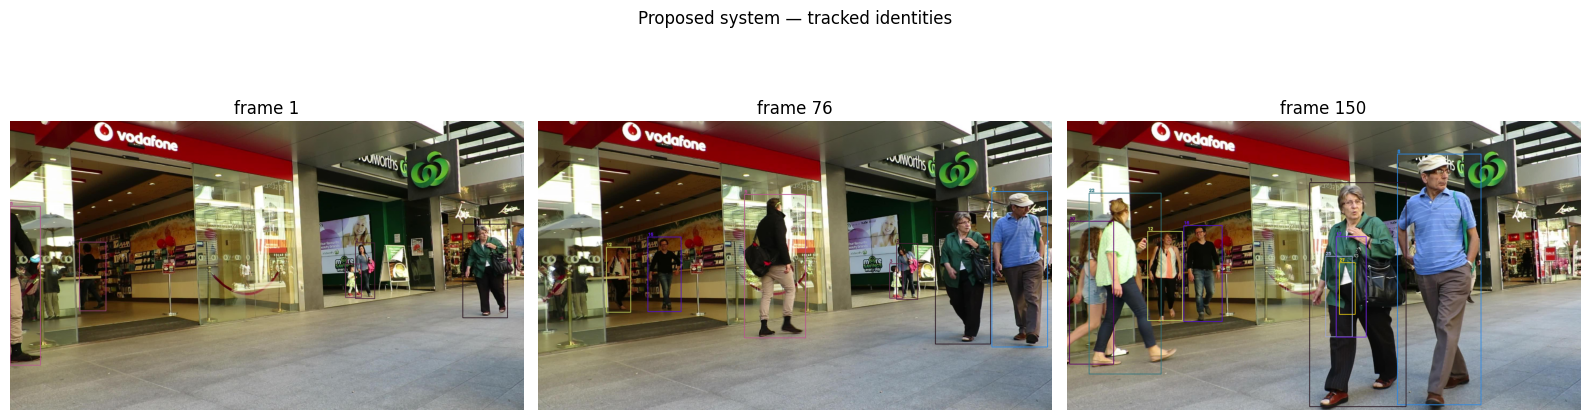

In [21]:
# Preview a few tracked frames from the proposed system
def preview_tracked(results, sample_frames=(0, len(FRAMES)//2, len(FRAMES)-1)):
    fig, axes = plt.subplots(1, len(sample_frames), figsize=(16, 5))
    for ax, idx in zip(axes, sample_frames):
        img = cv2.cvtColor(cv2.imread(FRAMES[idx]), cv2.COLOR_BGR2RGB)
        for tid, x1, y1, x2, y2 in results.get(idx + 1, []):
            c = ((37 * tid) % 255, (17 * tid) % 255, (29 * tid) % 255)
            cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), c, 2)
            cv2.putText(img, f"{tid}", (int(x1), int(y1) - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 2)
        ax.imshow(img); ax.set_title(f"frame {idx + 1}"); ax.axis("off")
    plt.suptitle("Proposed system — tracked identities"); plt.tight_layout(); plt.show()

preview_tracked(res_proposed)

## 8. Tracking Evaluation (MOTA, IDF1, ID switches)
We evaluate against the ground truth with `motmetrics`. Distances use IoU (max 0.5).
Key metrics:
* **MOTA** — overall accuracy (1 − (FN+FP+IDsw)/GT); higher is better.
* **IDF1** — identity-preservation F1; rewards keeping the *same* ID on an object.
* **ID switches** — how often a tracked identity jumps between objects (lower is better).
* **Precision / Recall** — detection quality within the tracker output.

In [22]:
import motmetrics as mm
import pandas as pd

# motmetrics 1.4 still calls np.asfarray, which was removed in NumPy 2.0
# (Colab ships NumPy 2.x). Restore a minimal shim so evaluation works.
if not hasattr(np, "asfarray"):
    np.asfarray = lambda a, dtype=np.float64: np.asarray(a, dtype=dtype)

def evaluate_tracking(results, gt, name):
    acc = mm.MOTAccumulator(auto_id=True)
    for fr in sorted(gt.keys()):
        gt_ids  = [t for (t, *_ ) in gt[fr]]
        gt_xywh = [[x1, y1, x2 - x1, y2 - y1] for (_, x1, y1, x2, y2) in gt[fr]]
        hyp = results.get(fr, [])
        hyp_ids  = [t for (t, *_ ) in hyp]
        hyp_xywh = [[x1, y1, x2 - x1, y2 - y1] for (_, x1, y1, x2, y2) in hyp]
        dists = mm.distances.iou_matrix(gt_xywh, hyp_xywh, max_iou=0.5)
        acc.update(gt_ids, hyp_ids, dists)
    mh = mm.metrics.create()
    summary = mh.compute(
        acc, name=name,
        metrics=["num_frames", "mota", "motp", "idf1",
                 "num_switches", "num_false_positives", "num_misses",
                 "precision", "recall"])
    return summary

sum_proposed = evaluate_tracking(res_proposed, GT, "Proposed (FRCNN+AdaptiveSORT)")
sum_baseline = evaluate_tracking(res_baseline, GT, "Baseline (COCO+GreedyIoU)")
track_summary = pd.concat([sum_baseline, sum_proposed])
print(mm.io.render_summary(
    track_summary,
    formatters=mm.metrics.create().formatters,
    namemap=mm.io.motchallenge_metric_names))
track_summary

                              num_frames  MOTA  MOTP  IDF1 IDs  FP  FN  Prcn  Rcll
Baseline (COCO+GreedyIoU)            150 39.6% 0.155 68.3%   6 402 262 67.8% 76.4%
Proposed (FRCNN+AdaptiveSORT)        150 77.0% 0.100 79.8%   7  79 169 92.3% 84.8%


,num_frames,mota,motp,idf1,num_switches,num_false_positives,num_misses,precision,recall
Baseline (COCO+GreedyIoU),150,0.396396,0.155214,0.683051,6,402,262,0.678400,0.763964
Proposed (FRCNN+AdaptiveSORT),150,0.770270,0.099883,0.798122,7,79,169,0.922549,0.847748


## 9. Consolidated Results

,System,mAP@0.5,mAP@.5:.95,MOTA,IDF1,ID switches,FPS
0,Baseline (COCO + Greedy IoU),0.591,0.449,0.396,0.683,6,2.45
1,Proposed (Fine-tuned + Adaptive SORT),0.693,0.517,0.770,0.798,7,2.40


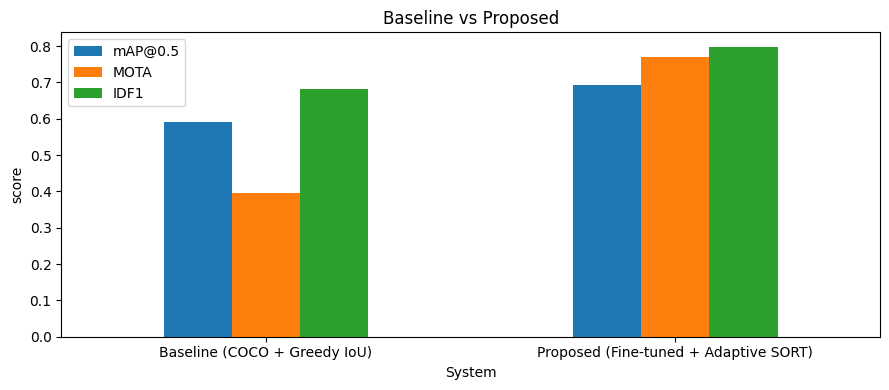

In [23]:
results_table = pd.DataFrame({
    "System":     ["Baseline (COCO + Greedy IoU)", "Proposed (Fine-tuned + Adaptive SORT)"],
    "mAP@0.5":    [round(map_baseline["map_50"], 3), round(map_finetuned["map_50"], 3)],
    "mAP@.5:.95": [round(map_baseline["map"], 3),    round(map_finetuned["map"], 3)],
    "MOTA":       [round(sum_baseline["mota"].iloc[0], 3),
                   round(sum_proposed["mota"].iloc[0], 3)],
    "IDF1":       [round(sum_baseline["idf1"].iloc[0], 3),
                   round(sum_proposed["idf1"].iloc[0], 3)],
    "ID switches":[int(sum_baseline["num_switches"].iloc[0]),
                   int(sum_proposed["num_switches"].iloc[0])],
    "FPS":        [round(fps_baseline, 2), round(fps_proposed, 2)],
})
display(results_table)

ax = results_table.set_index("System")[["mAP@0.5", "MOTA", "IDF1"]].plot(
    kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Baseline vs Proposed"); ax.set_ylabel("score"); plt.tight_layout(); plt.show()

## 10. Justification & Analysis

**Why Faster R-CNN?** It is a two-stage detector with a Region Proposal Network that gives
high localisation accuracy for small/occluded pedestrians — well suited to crowded MOT
scenes. We fine-tuned from COCO weights because the target objects (pedestrians) overlap
with COCO's *person* class, so transfer learning converges in a few epochs on a small
sequence.

**Effect of fine-tuning (detection mAP).** The fine-tuned detector should improve mAP over
the raw COCO model because it adapts to this sequence's camera angle, scale, and background.
If the gain is small, the COCO *person* prior is already strong for this domain; if the
fine-tuned model *underperforms* on the validation tail, likely causes are (a) **overfitting**
to the first 80% of frames — the temporal split means train/val come from different parts of
the same walk, causing domain shift — or (b) too few epochs (**underfitting**). Increasing
`EPOCHS` and using more sequences would address both.

**Effect of the tracker (MOTA / IDF1 / ID-switches).** The proposed **adaptive SORT** is
expected to beat the greedy IoU baseline on **IDF1** and **ID switches** because:
* the **Kalman filter** predicts motion, so associations survive short detection gaps;
* the **temporal-consistency** `min_hits` gate suppresses one-frame false positives that
  otherwise spawn spurious IDs;
* **adaptive gating** widens the match region for fast walkers, preventing broken tracks
  (which show up as ID switches).

**Speed (FPS).** The two-stage detector dominates runtime, so both systems run at similar
FPS; the tracker adds negligible overhead. This is the classic **accuracy-vs-speed**
trade-off — a one-stage detector (YOLO/RetinaNet) would raise FPS at some cost to mAP.

**Limitations.** Single short sequence, IoU-only association (no appearance/Re-ID features,
so long occlusions still cause switches), and evaluation on a temporal hold-out rather than
unseen sequences. Deep-SORT-style appearance embeddings and multi-sequence training are the
natural next steps.


## 11. Conclusion & Deliverables

We built an end-to-end multi-object tracking system that:
1. **preprocesses & augments** MOT video frames (resize/normalize via tensor conversion,
   random flip/crop/color-jitter);
2. **detects** pedestrians with a COCO-pretrained **Faster R-CNN fine-tuned** on the sequence;
3. **tracks** them with an **adaptive SORT** tracker featuring **temporal-consistency checks**
   and **speed-adaptive association**;
4. is **evaluated** with detection mAP and tracking MOTA / IDF1 / ID-switches / FPS against a
   baseline, with analysis of the results.

**Video explanation (≤ 4 min):** _<add your video link here and in the shared Google Sheet>_
